# Name = M.Abuzar Shoukat
# Reg. No. = 04102313064
# Date = 13/09/26


## Importing Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


### Loading the Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Dataset shape:', df.shape)

df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview

### Column Information:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Statistical Summary:

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


###  Missing Values:


In [5]:
print('Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0])
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


Missing Values:
Series([], dtype: int64)


### Target Variable:

In [6]:
print('Churn Distribution:')
print(df['Churn'].value_counts())
print()
print('Churn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 2. Numerical Features Analysis

### Visualization 1: Tenure Distribution


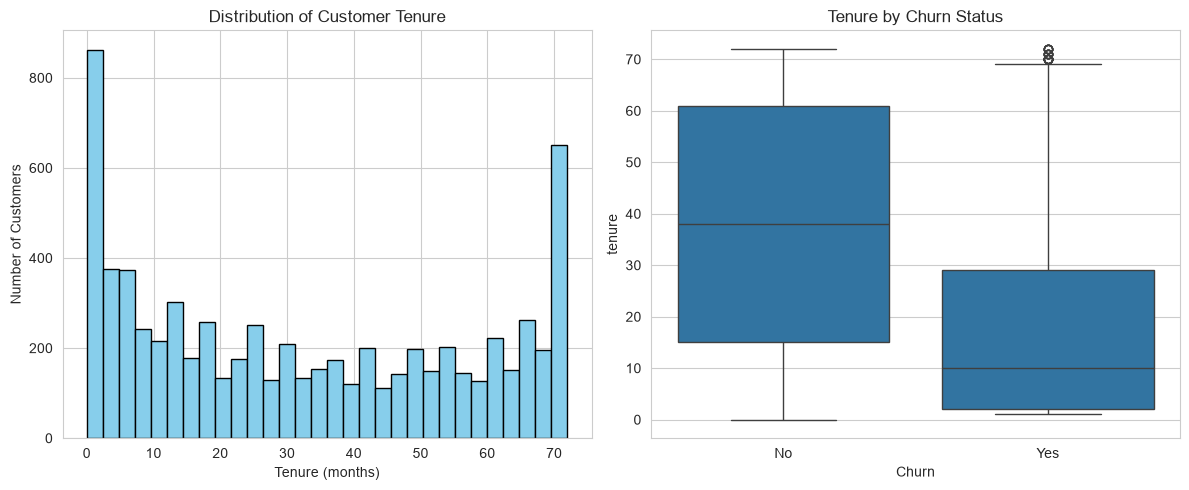

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure')
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')
plt.tight_layout()
plt.show()


### Visualization 2: Monthly Charges


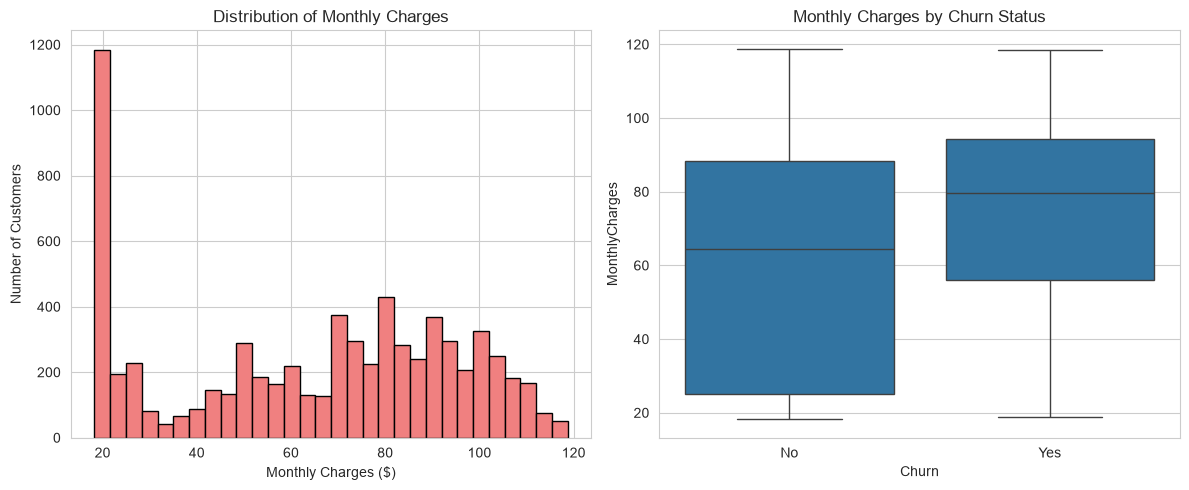

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges')
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show()


### Visualization 3: Total Charges

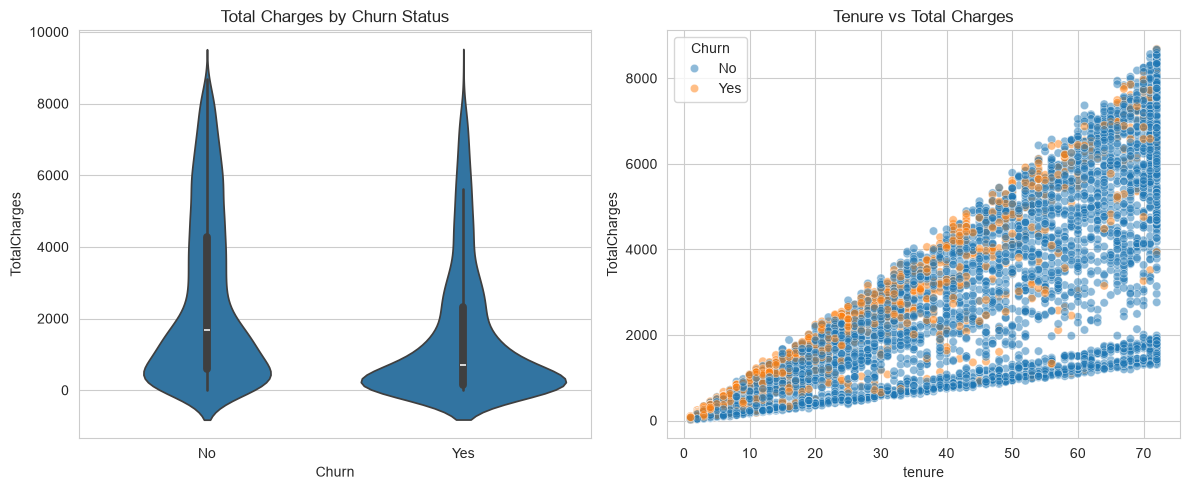

In [9]:
df_clean = df[df['TotalCharges'].notna()]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x='Churn', y='TotalCharges', data=df_clean)
plt.title('Total Charges by Churn Status')
plt.subplot(1, 2, 2)
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df_clean,
alpha=0.5)
plt.title('Tenure vs Total Charges')
plt.tight_layout()
plt.show()

## 3. Categorical Features Analysis

### Visualization 4: Contract Type

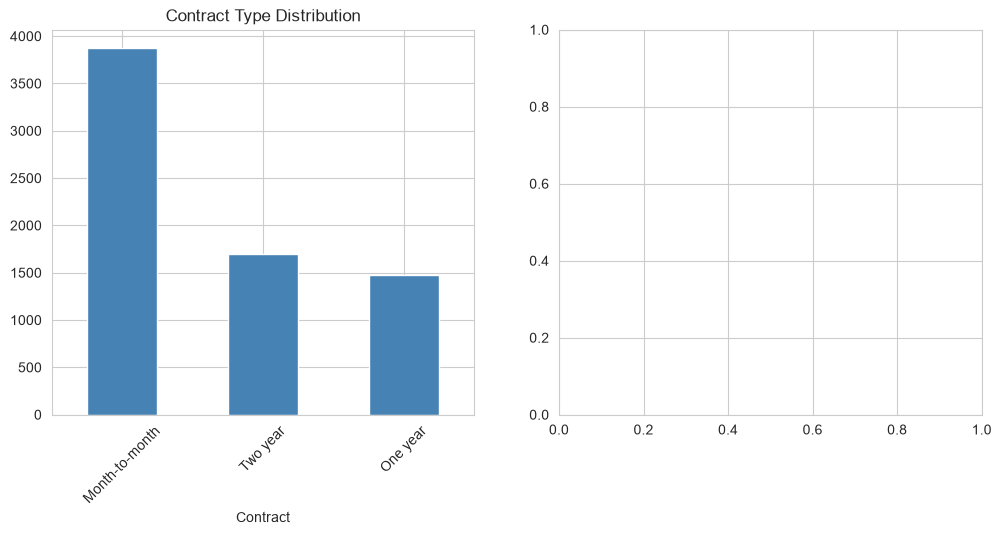

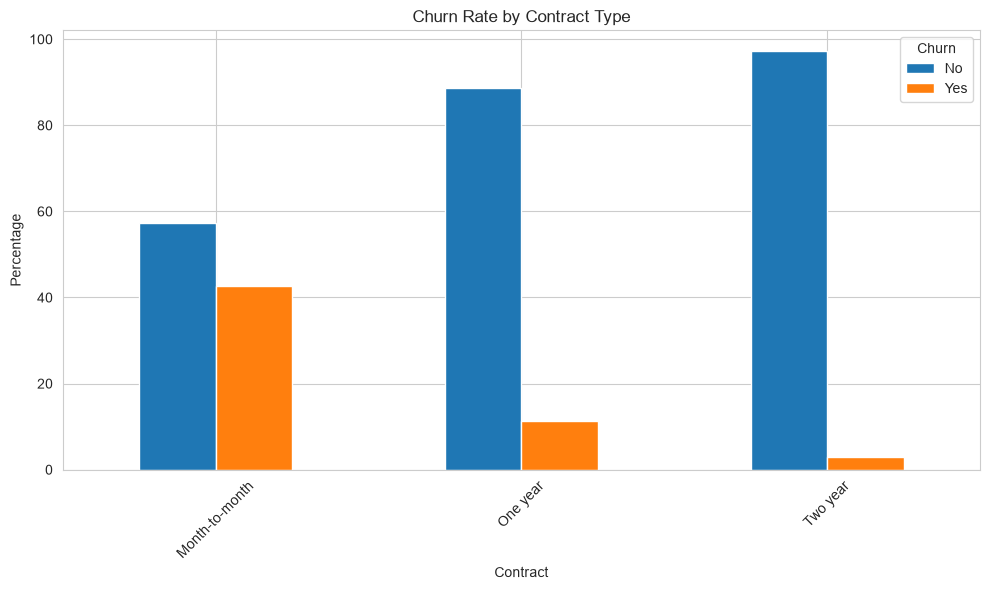

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Contract'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Contract Type Distribution')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualization 5: Internet Service


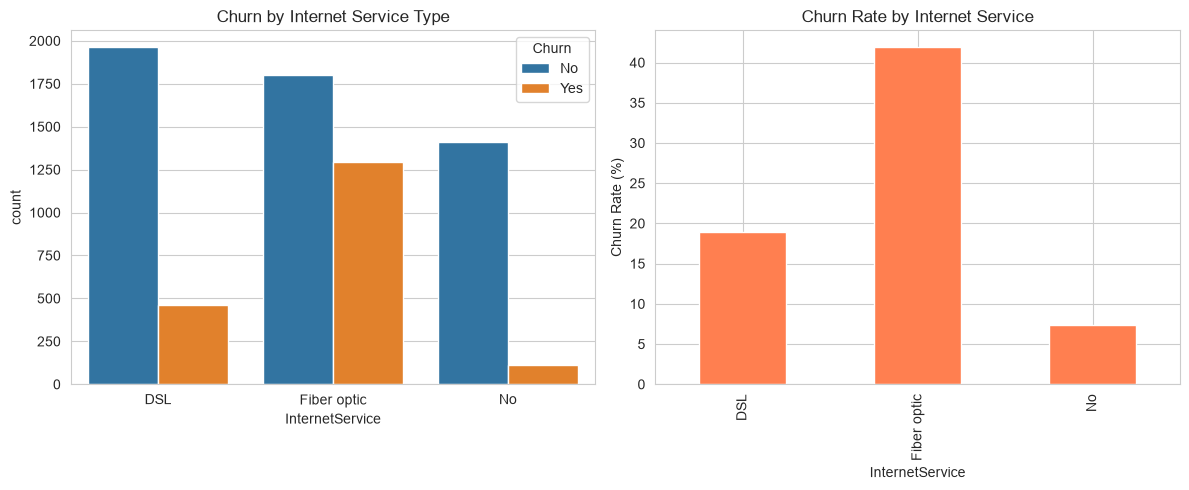

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.subplot(1, 2, 2)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'],
normalize='index') * 100
internet_churn['Yes'].plot(kind='bar', color='coral')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()


### Visualization 6: Payment Method

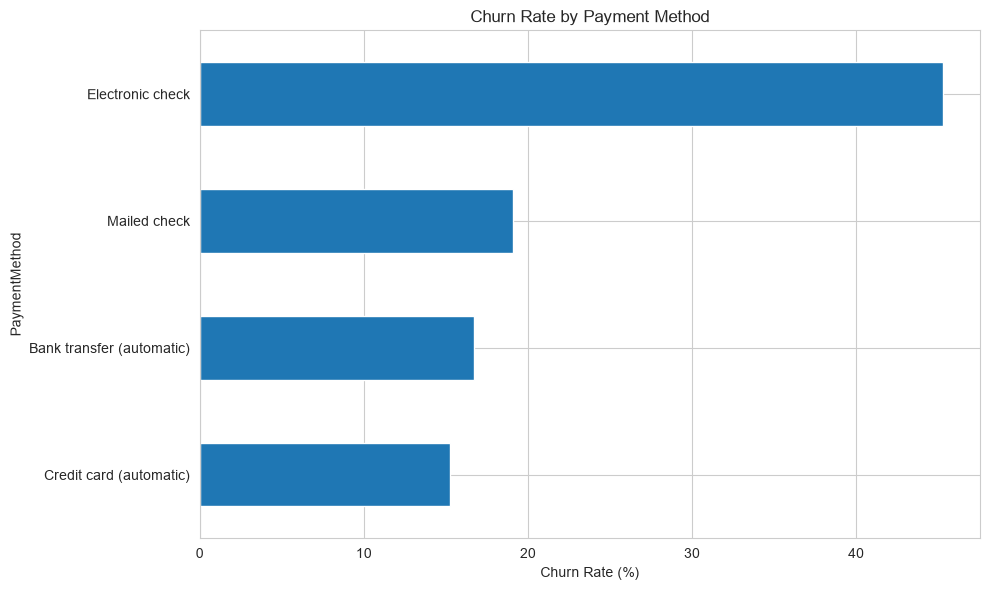

In [12]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 6))

payment_churn['Yes'].sort_values().plot(kind='barh')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

##  Correlation Analysis

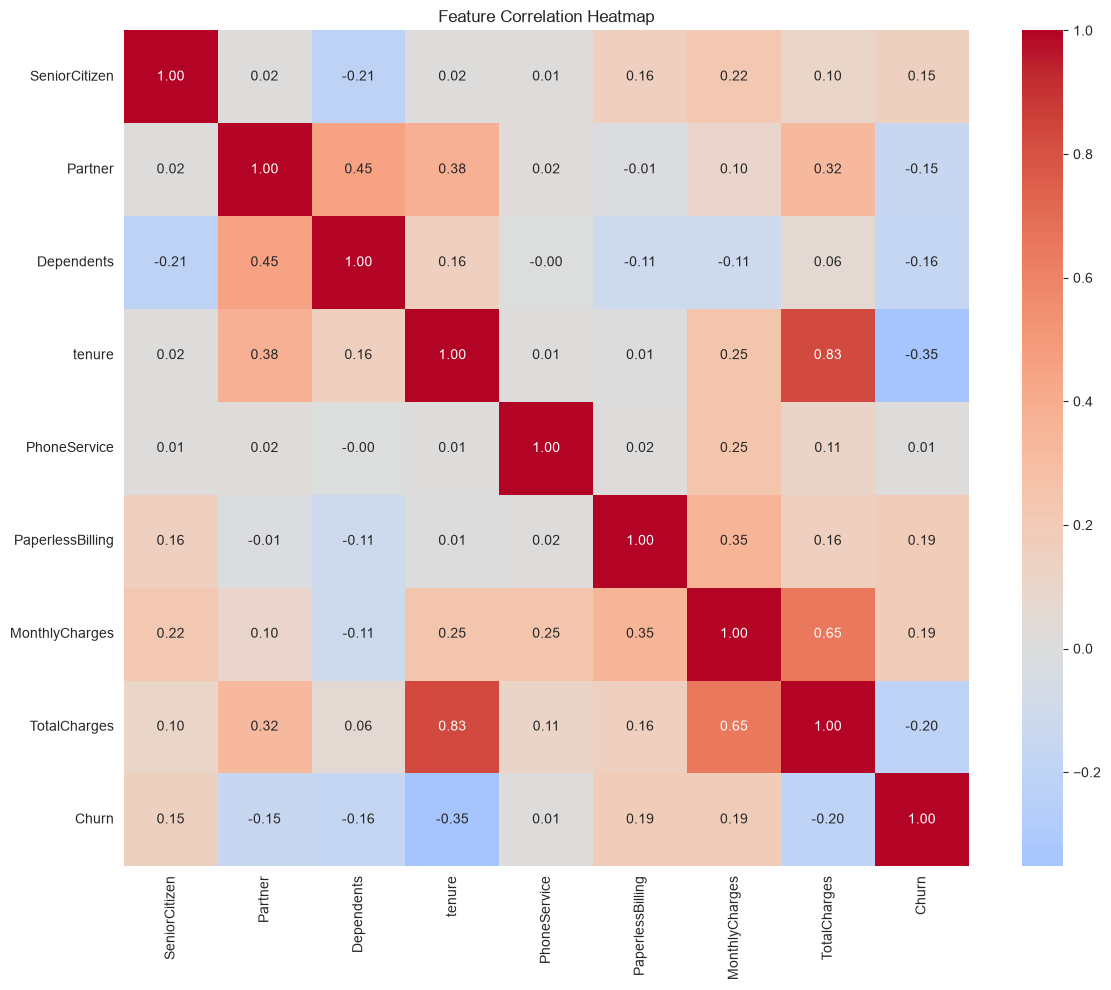

In [13]:
# Prepare numeric data
df_numeric = df.copy()
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService',
'PaperlessBilling']
for col in binary_cols:
 if col in df_numeric.columns:
   df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})
numeric_features = df_numeric.select_dtypes(include=[np.number])
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_features.corr(), annot=True, fmt='.2f', cmap='coolwarm',
center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Insights Summary 

### 1. High-Risk Customer Characteristics
* **Contracts:** People on month-to-month plans are way more likely to cancel compared to those on 1-year or 2-year contracts.
* **Time with company:** The first few months are the riskiest. If a customer stays past the beginning, they usually stick around for the long haul.
* **Costs:** Customers paying higher monthly bills are much quicker to leave.
* **Internet Type:** Fiber optic customers are leaving at much higher rates than those using DSL or no internet at all.
* **Payment Method:** People who pay manually with electronic checks cancel a lot more often than people who use automatic payments like credit cards or bank transfers.

### 2. Patterns Observed
* **Loyalty takes time:** There is a clear link between how long someone has been a customer and how likely they are to stay. Keeping new customers happy early on is the biggest challenge.
* **Convenience matters:** Customers who use manual payment methods and have flexible month-to-month contracts overlap a lot, and this group is leaving the fastest.
## Key Findings 
* **Overall Churn Rate:** 26.54% (1,869 of 7,043 customers).
* **Contract Type:** Month-to-month contracts are the strongest churn driver, churning at ~42% compared to ~11% for one-year and ~3% for two-year contracts.
* **Customer Tenure:** Customers with shorter tenure are far more likely to leave, with most churn happening early in the relationship.
* **Internet Service:** Fiber optic internet subscribers churn at ~42%, notably higher than DSL (~19%) or customers with no internet service (~7%).
* **Payment Method:** Electronic check users have the highest churn rate (~45%), nearly three times that of automatic payment methods like bank transfers or credit cards.